Loading data...
Zero-padding and mapping iq_samplesTX1.csv...
Zero-padding and mapping iq_samplesTX2.csv...


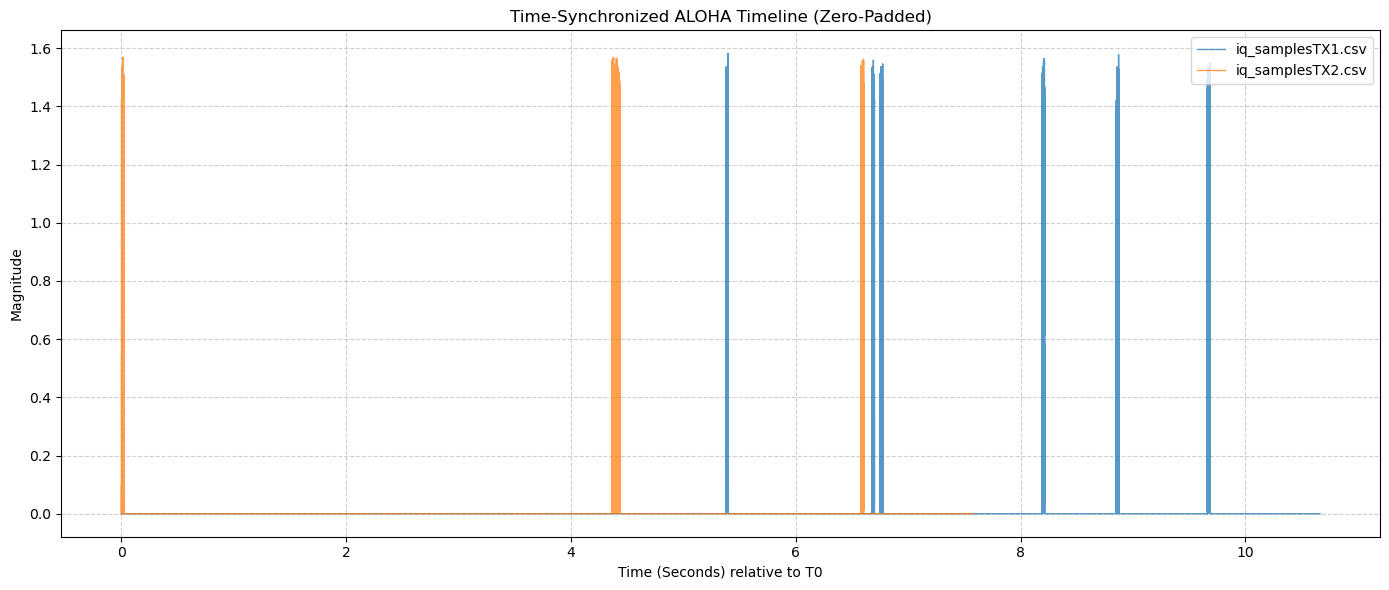

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import glob

# Configuration
SAMPLE_RATE = 48000.0  # Make sure this matches the sample rate in your flowgraph

# 1. Find all CSV files and calculate the absolute starting time (T0)
file_list = glob.glob('iq_samples*.csv')
if not file_list:
    print("No CSV files found in the directory.")
    exit()

min_timestamps = []
dataframes = {}

print("Loading data...")
for file in file_list:
    df = pd.read_csv(file)
    # Convert string timestamps to actual datetime objects
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    min_timestamps.append(df['timestamp'].min())
    dataframes[file] = df

# T0 is the exact moment the very first node started transmitting
T0 = min(min_timestamps)

plt.figure(figsize=(14, 6))

# 2. Process each file and rebuild the continuous timeline
for file, df in dataframes.items():
    print(f"Zero-padding and mapping {file}...")
    
    # Pre-allocate an array based on the last timestamp in this specific file
    max_time_sec = (df['timestamp'].max() - T0).total_seconds()
    buffer_size = int(max_time_sec * SAMPLE_RATE) + int(SAMPLE_RATE) 
    
    i_out = np.zeros(buffer_size)
    q_out = np.zeros(buffer_size)
    
    current_write_index = 0
    
    for _, row in df.iterrows():
        # Calculate exactly where this chunk SHOULD start on the timeline
        target_index = int((row['timestamp'] - T0).total_seconds() * SAMPLE_RATE)
        
        # We use max() to perfectly glue continuous packet chunks (like 1024 + 128) 
        # back together, while allowing zero-padded gaps for separate packets.
        start_idx = max(current_write_index, target_index)
        
        # Safely parse the string arrays
        i_chunk = ast.literal_eval(row['i_values'])
        q_chunk = ast.literal_eval(row['q_values'])
        end_idx = start_idx + len(i_chunk)
        
        # Dynamically expand the array if the samples push past our buffer
        if end_idx > len(i_out):
            padding = np.zeros(end_idx - len(i_out) + int(SAMPLE_RATE))
            i_out = np.concatenate((i_out, padding))
            q_out = np.concatenate((q_out, padding))
            
        # Insert the actual RF samples into the timeline
        i_out[start_idx:end_idx] = i_chunk
        q_out[start_idx:end_idx] = q_chunk
        
        # Move the pointer forward
        current_write_index = end_idx

    # Calculate signal magnitude: M = sqrt(I^2 + Q^2)
    magnitude = np.sqrt(i_out**2 + q_out**2)
    
    # Create a time axis (in Seconds) for plotting
    time_axis = np.arange(len(magnitude)) / SAMPLE_RATE
    
    plt.plot(time_axis, magnitude, label=f'{file}', linewidth=1.0, alpha=0.75)

# 3. Format and display the plot
plt.title('Time-Synchronized ALOHA Timeline (Zero-Padded)')
plt.xlabel('Time (Seconds) relative to T0')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the plot or show it on screen
plt.savefig('aloha_timeline.png', dpi=300)
plt.show()

Mapping User 1 and User 2 to shared timeline...
Adding complex signals together...
Done! Plot saved as 'rf_collision_with_legends.png'


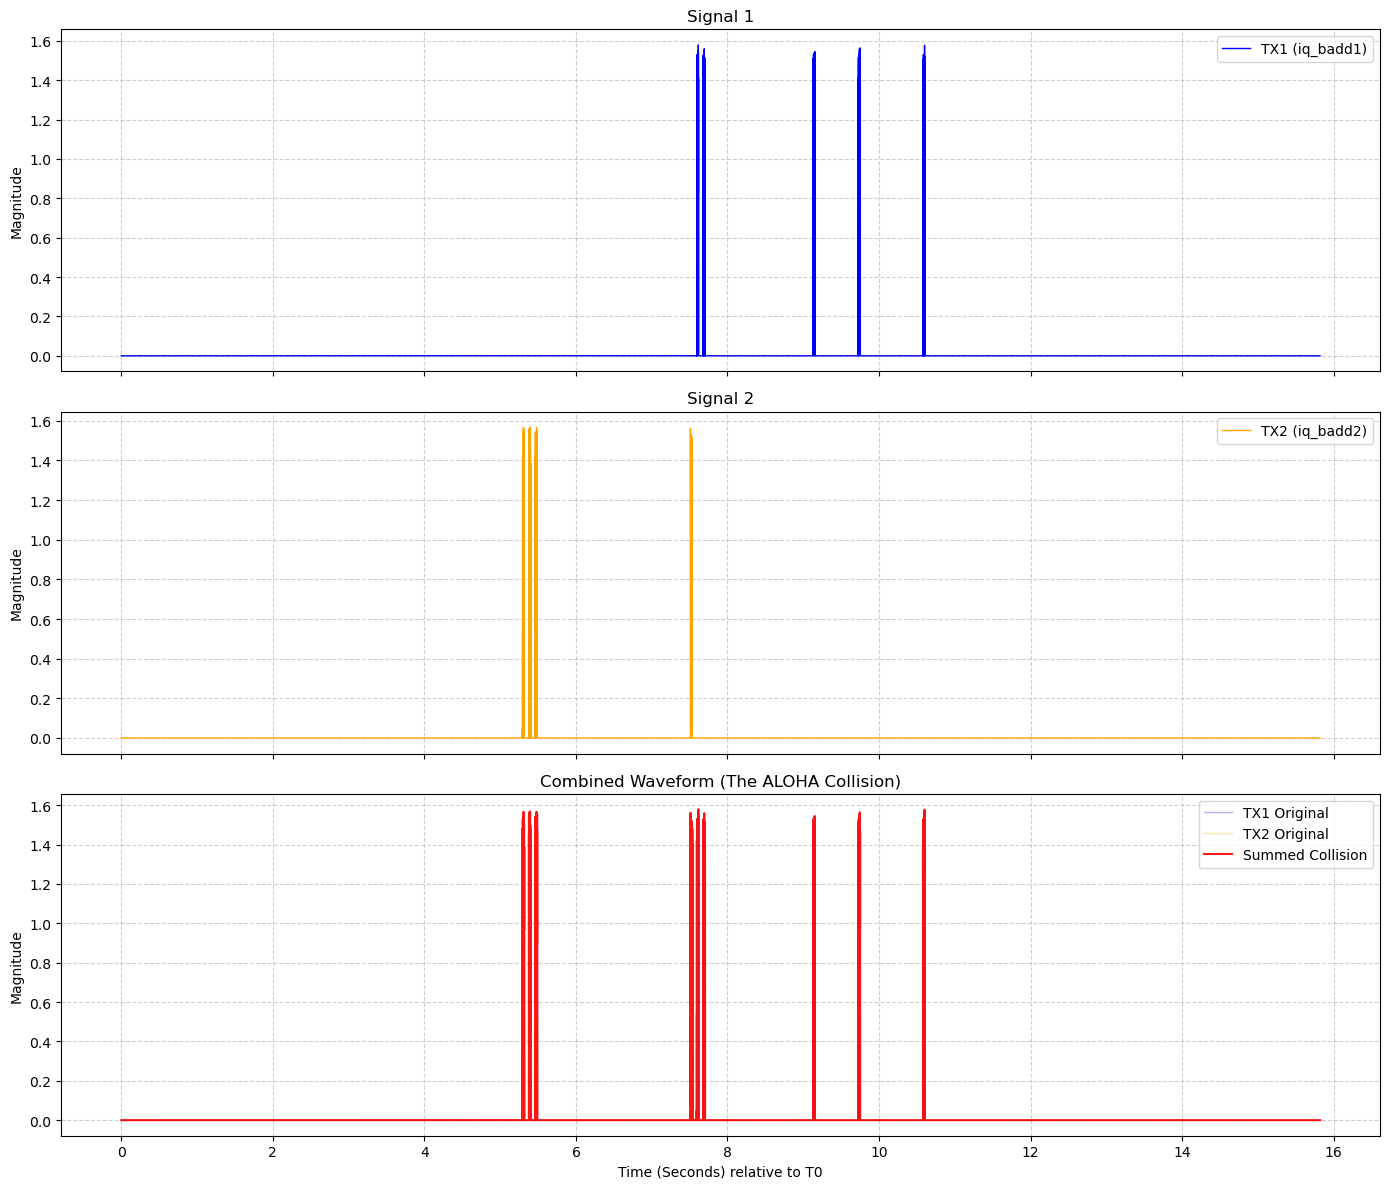

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os

# --- Configuration ---
SAMPLE_RATE = 48000.0  # Make sure this matches your GNU Radio flowgraph
FILE_1 = 'iq_badd1.csv'
FILE_2 = 'iq_badd2.csv'

def load_file_metadata(filename):
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found.")
        return None
    df = pd.read_csv(filename)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

def extract_and_pad_iq(df, T0, total_samples):
    """Maps bursty packets onto a continuous, zero-padded time axis."""
    i_out = np.zeros(total_samples)
    q_out = np.zeros(total_samples)
    
    current_write_index = 0
    for _, row in df.iterrows():
        target_index = int((row['timestamp'] - T0).total_seconds() * SAMPLE_RATE)
        start_idx = max(current_write_index, target_index)
        
        i_chunk = ast.literal_eval(row['i_values'])
        q_chunk = ast.literal_eval(row['q_values'])
        end_idx = start_idx + len(i_chunk)
        
        if end_idx > total_samples:
            end_idx = total_samples
            i_chunk = i_chunk[:(end_idx - start_idx)]
            q_chunk = q_chunk[:(end_idx - start_idx)]
            
        i_out[start_idx:end_idx] = i_chunk
        q_out[start_idx:end_idx] = q_chunk
        current_write_index = end_idx
        
    return i_out, q_out

# 1. Load Data
df1 = load_file_metadata(FILE_1)
df2 = load_file_metadata(FILE_2)

if df1 is None or df2 is None:
    print("Please make sure both iq_badd1.csv and iq_badd2.csv are in the folder.")
    exit()

# Find the absolute starting point (T0)
T0 = min(df1['timestamp'].min(), df2['timestamp'].min())

# Calculate total timeline length with a 1-second buffer
max_time_sec = max(
    (df1['timestamp'].max() - T0).total_seconds(),
    (df2['timestamp'].max() - T0).total_seconds()
)
TOTAL_SAMPLES = int(max_time_sec * SAMPLE_RATE) + int(SAMPLE_RATE)

# 2. Extract and Map
print("Mapping User 1 and User 2 to shared timeline...")
i1, q1 = extract_and_pad_iq(df1, T0, TOTAL_SAMPLES)
i2, q2 = extract_and_pad_iq(df2, T0, TOTAL_SAMPLES)

# 3. Simulate RF Collision (Complex Addition)
print("Adding complex signals together...")
i_summed = i1 + i2
q_summed = q1 + q2

mag1 = np.sqrt(i1**2 + q1**2)
mag2 = np.sqrt(i2**2 + q2**2)
mag_summed = np.sqrt(i_summed**2 + q_summed**2)

time_axis = np.arange(TOTAL_SAMPLES) / SAMPLE_RATE

# 4. Plot the Results
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot BADD1 (Top)
axs[0].plot(time_axis, mag1, color='blue', linewidth=1, label='TX1 (iq_badd1)')
axs[0].set_title('Signal 1')
axs[0].set_ylabel('Magnitude')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(loc='upper right') # <-- Added Legend

# Plot BADD2 (Middle)
axs[1].plot(time_axis, mag2, color='orange', linewidth=1, label='TX2 (iq_badd2)')
axs[1].set_title('Signal 2')
axs[1].set_ylabel('Magnitude')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(loc='upper right') # <-- Added Legend

# Plot SUMMED with Overlays (Bottom)
# Note the alpha values: TX1 and TX2 are semi-transparent so the red Summed line stands out
axs[2].plot(time_axis, mag1, color='blue', linewidth=1, alpha=0.3, label='TX1 Original')
axs[2].plot(time_axis, mag2, color='orange', linewidth=1, alpha=0.3, label='TX2 Original')
axs[2].plot(time_axis, mag_summed, color='red', linewidth=1.5, alpha=0.9, label='Summed Collision')
axs[2].set_title('Combined Waveform (The ALOHA Collision)')
axs[2].set_xlabel('Time (Seconds) relative to T0')
axs[2].set_ylabel('Magnitude')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend(loc='upper right') # <-- Added Legend for all 3 lines

plt.tight_layout()
plt.savefig('rf_collision_with_legends.png', dpi=300)
print("Done! Plot saved as 'rf_collision_with_legends.png'")
plt.show()

Scanning files to establish universal timeline...

Processing 'iq_samples' group...
  -> Mapping iq_samplesTX1.csv...
  -> Mapping iq_samplesTX2.csv...

Processing 'iq_badd' group...
  -> Mapping iq_badd1.csv...
  -> Mapping iq_badd2.csv...

Comparing the two additions...
Max Absolute Error between the two additions: 1.5824183226

Done! Plot saved as 'addition_comparison_check.png'


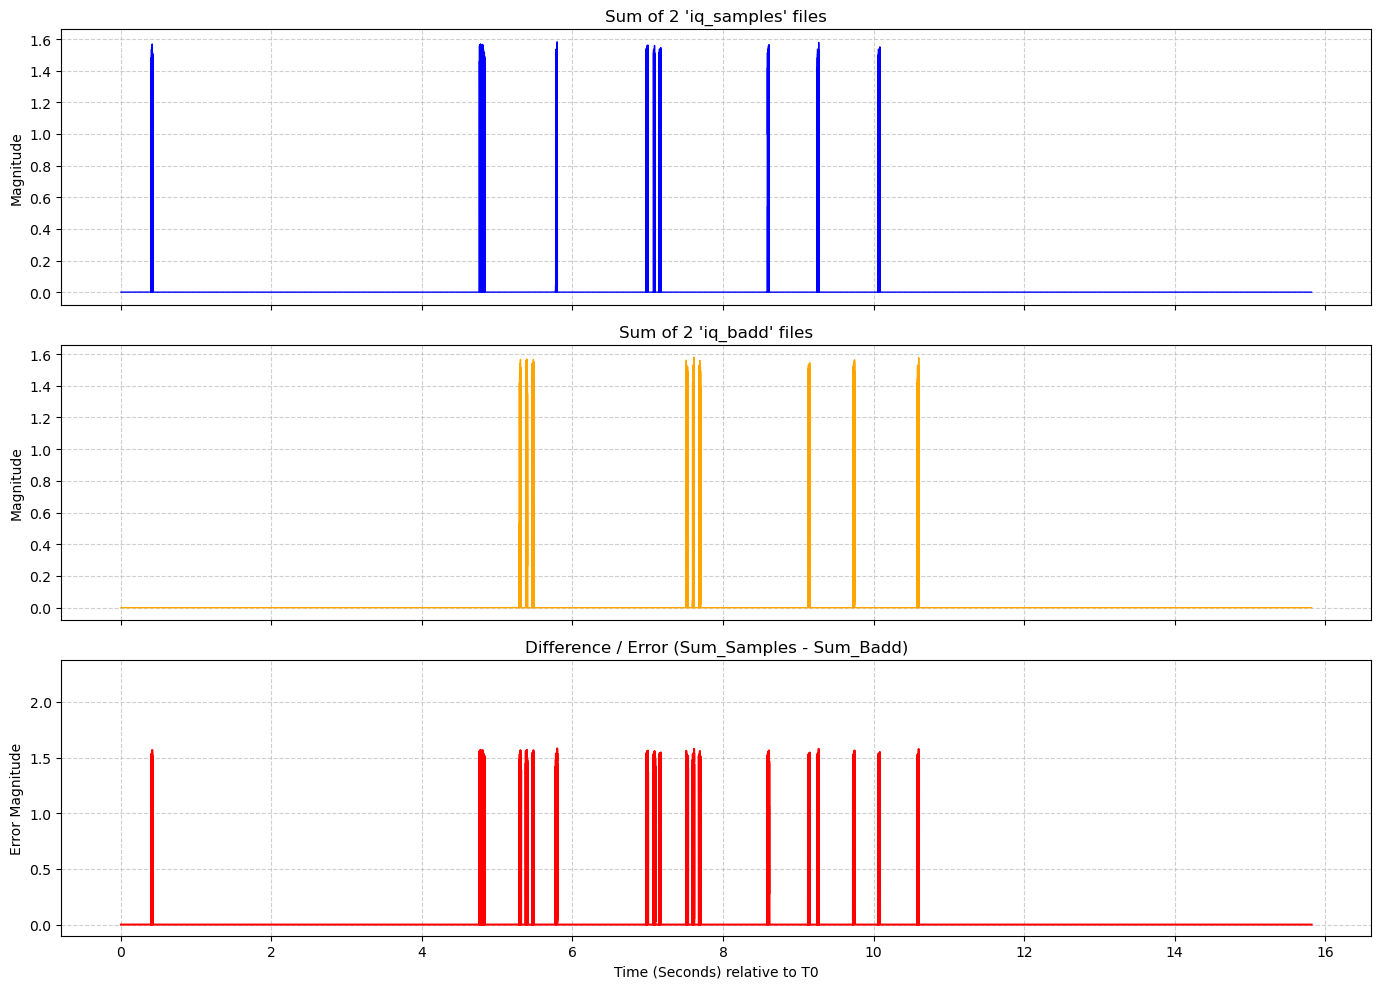

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import glob
import os

# --- Configuration ---
SAMPLE_RATE = 48000.0  # Make sure this matches your GNU Radio flowgraph

def extract_and_pad_iq(filename, T0, total_samples):
    """Reads a CSV, maps the bursty packets onto the universal zero-padded timeline."""
    if not os.path.exists(filename):
        print(f"  [!] Warning: {filename} not found.")
        return np.zeros(total_samples, dtype=np.complex128)
        
    df = pd.read_csv(filename)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    i_out = np.zeros(total_samples)
    q_out = np.zeros(total_samples)
    
    current_write_index = 0
    for _, row in df.iterrows():
        target_index = int((row['timestamp'] - T0).total_seconds() * SAMPLE_RATE)
        start_idx = max(current_write_index, target_index)
        
        i_chunk = ast.literal_eval(row['i_values'])
        q_chunk = ast.literal_eval(row['q_values'])
        end_idx = start_idx + len(i_chunk)
        
        if end_idx > total_samples:
            end_idx = total_samples
            i_chunk = i_chunk[:(end_idx - start_idx)]
            q_chunk = q_chunk[:(end_idx - start_idx)]
            
        i_out[start_idx:end_idx] = i_chunk
        q_out[start_idx:end_idx] = q_chunk
        current_write_index = end_idx
        
    return i_out + 1j * q_out  # Return as true complex numbers

# 1. Identify all files
samples_files = glob.glob('iq_samples*.csv')
badd_files = glob.glob('iq_badd*.csv')

all_files = samples_files + badd_files

if not all_files:
    print("No CSV files found in the current directory.")
    exit()

# 2. Find Universal T0 and Max Time
print("Scanning files to establish universal timeline...")
min_timestamps = []
max_timestamps = []

for f in all_files:
    df = pd.read_csv(f, usecols=['timestamp']) # Only load timestamps for speed
    ts = pd.to_datetime(df['timestamp'])
    min_timestamps.append(ts.min())
    max_timestamps.append(ts.max())

T0 = min(min_timestamps)
max_time_sec = (max(max_timestamps) - T0).total_seconds()
TOTAL_SAMPLES = int(max_time_sec * SAMPLE_RATE) + int(SAMPLE_RATE) # +1 sec buffer

# 3. Process Group 1: iq_samples*.csv
print("\nProcessing 'iq_samples' group...")
sum_samples = np.zeros(TOTAL_SAMPLES, dtype=np.complex128)
for f in samples_files:
    print(f"  -> Mapping {f}...")
    sum_samples += extract_and_pad_iq(f, T0, TOTAL_SAMPLES)

# 4. Process Group 2: iq_badd*.csv
print("\nProcessing 'iq_badd' group...")
sum_badd = np.zeros(TOTAL_SAMPLES, dtype=np.complex128)
for f in badd_files:
    print(f"  -> Mapping {f}...")
    sum_badd += extract_and_pad_iq(f, T0, TOTAL_SAMPLES)

# 5. Calculate the Mathematical Error (Difference)
print("\nComparing the two additions...")
error_complex = sum_samples - sum_badd
error_magnitude = np.abs(error_complex)

max_error = np.max(error_magnitude)
print(f"Max Absolute Error between the two additions: {max_error:.10f}")

if max_error < 1e-6:
    print("SUCCESS: The RF Level Additions are mathematically identical!")
else:
    print("WARNING: Discrepancies found between the two sums.")

# 6. Plot the Results
time_axis = np.arange(TOTAL_SAMPLES) / SAMPLE_RATE

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot Sum of iq_samples
axs[0].plot(time_axis, np.abs(sum_samples), color='blue', linewidth=1)
axs[0].set_title(f"Sum of {len(samples_files)} 'iq_samples' files")
axs[0].set_ylabel('Magnitude')
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot Sum of iq_badd
axs[1].plot(time_axis, np.abs(sum_badd), color='orange', linewidth=1)
axs[1].set_title(f"Sum of {len(badd_files)} 'iq_badd' files")
axs[1].set_ylabel('Magnitude')
axs[1].grid(True, linestyle='--', alpha=0.6)

# Plot the Error Difference
axs[2].plot(time_axis, error_magnitude, color='red', linewidth=1.5)
axs[2].set_title('Difference / Error (Sum_Samples - Sum_Badd)')
axs[2].set_xlabel('Time (Seconds) relative to T0')
axs[2].set_ylabel('Error Magnitude')
axs[2].grid(True, linestyle='--', alpha=0.6)

# Force the Y-axis of the error plot to show 0 clearly even if error is extremely small
axs[2].set_ylim(-0.1, max(0.1, max_error * 1.5))

plt.tight_layout()
plt.savefig('addition_comparison_check.png', dpi=300)
print("\nDone! Plot saved as 'addition_comparison_check.png'")
plt.show()

In [2]:
import pandas as pd
import numpy as np
import json

def load_complex_iq(filename):
    df = pd.read_csv(filename)
    # Parse the string-encoded lists into flat numpy arrays
    i = np.concatenate([json.loads(row) for row in df['i_values']])
    q = np.concatenate([json.loads(row) for row in df['q_values']])
    return i + 1j * q

# Load data
tx_c = load_complex_iq('iq_samplesTX1.csv')
out_c = load_complex_iq('iq_badd1.csv')

# 1. Check for the signal presence using correlation
# (Direct comparison fails because of leading zeros in badd1)
correlation = np.abs(np.correlate(out_c, tx_c, mode='valid'))
best_match_idx = np.argmax(correlation)

print(f"Signal begins at index: {best_match_idx}")

# 2. Check if the block at that index matches TX1
# Note: As found in analysis, only the first 2/3 of TX1 is present in badd1
match = np.allclose(out_c[best_match_idx : best_match_idx + 2304], 
                    tx_c[:2304], atol=1e-5)
print(f"First two blocks match: {match}")

Signal begins at index: 142193
First two blocks match: False
